# GENDF Fe-56 MT=2 Uncertainty Diagnostic

Verify that multigroup covariance uncertainty extraction from GENDF (NJOY ERRORR) 
files is consistent across all code paths: `get_uncertainty()`, `to_heatmap_data()`,
and direct diagonal extraction.

**Key check**: NJOY ERRORR produces *relative* covariance matrices, so
`sqrt(diag)` gives fractional standard deviations directly. Dividing by
cross section would be double-normalization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from kika.cov.parse_covmat import read_covfil

GENDF_PATH = '/share_snc/snc/JuanMonleon/COV/cov/50/600/260560_50.06.xs.gendf'
cov = read_covfil(GENDF_PATH)

print(f"Groups: {cov.num_groups}")
print(f"Isotopes: {cov.isotopes}")
print(f"Reactions: {cov.reactions}")
print(f"is_relative list: {cov.is_relative}")
print(f"Cross sections available: {list(cov.cross_sections.keys())}")
print(f"Energy grid: {len(cov.energy_grid)} boundaries")

Groups: 56
Isotopes: [26056]
Reactions: [1, 2, 4, 16, 22, 28, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 102, 103, 104, 105, 106, 107, 111, 112, 115]
is_relative list: [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, Tr

In [2]:
# Inspect the raw diagonal of the MT=2 covariance matrix
# Must find the correct matrix: (zaid, 2) -> (zaid, 2) diagonal block
zaid = cov.isotopes[0]

# Find the diagonal block for MT=2
mt2_diag_idx = None
for i, (ir, rr, ic, rc) in enumerate(zip(
    cov.isotope_rows, cov.reaction_rows, cov.isotope_cols, cov.reaction_cols)):
    if ir == zaid and rr == 2 and ic == zaid and rc == 2:
        mt2_diag_idx = i
        break

print(f"MT=2 diagonal block at matrices[{mt2_diag_idx}]")
mat = cov.matrices[mt2_diag_idx]
raw_diag = np.diag(mat)

print(f"Matrix shape: {mat.shape}")
print(f"Raw diagonal (first 10): {raw_diag[:10]}")
print(f"sqrt(diag) fractional (first 10): {np.sqrt(np.maximum(raw_diag, 0))[:10]}")
print(f"sqrt(diag) as percent (first 10): {np.sqrt(np.maximum(raw_diag, 0))[:10] * 100}")
print(f"\nMax raw diag: {raw_diag.max():.6e}")
print(f"Max uncertainty (%): {np.sqrt(np.maximum(raw_diag, 0)).max() * 100:.2f}%")

# Also show what the full_cov diagonal gives (assembled from ALL blocks)
pairs = cov._get_param_pairs()
G = cov.num_groups
block_idx = pairs.index((zaid, 2))
full_cov = cov.covariance_matrix
full_diag = np.diag(full_cov)[block_idx*G : (block_idx+1)*G]
print(f"\nFull assembled diagonal (first 10): {full_diag[:10]}")
print(f"Full == raw diagonal? {np.allclose(full_diag, raw_diag, equal_nan=True)}")

MT=2 diagonal block at matrices[2]
Matrix shape: (56, 56)
Raw diagonal (first 10): [0.01024778 0.00621669 0.00440997 0.00306334 0.00303405 0.00290332
 0.00244675 0.00252091 0.00212305 0.00212222]
sqrt(diag) fractional (first 10): [0.10123132 0.07884599 0.06640759 0.05534749 0.05508225 0.05388249
 0.04946462 0.05020868 0.04607651 0.04606755]
sqrt(diag) as percent (first 10): [10.12313193  7.88459891  6.64075899  5.53474932  5.50822476  5.38824925
  4.94646237  5.02086845  4.60765125  4.60675482]

Max raw diag: 1.024778e-02
Max uncertainty (%): 10.12%

Full assembled diagonal (first 10): [0.01024778 0.00621669 0.00440997 0.00306334 0.00303405 0.00290332
 0.00244675 0.00252091 0.00212305 0.00212222]
Full == raw diagonal? True


In [3]:
# Compare three methods of computing uncertainty
# Method 1: get_uncertainty() -- library API
unc_get = cov.get_uncertainty(zaid, 2)
unc_get_pct = unc_get * 100

# Method 2: to_heatmap_data() -- used by heatmap plotting
heatmap_data = cov.to_heatmap_data(nuclide=zaid, mt=2)
unc_heatmap_pct = heatmap_data.uncertainty_data[2]

# Method 3: Direct from diagonal block matrix
unc_block_pct = np.sqrt(np.maximum(raw_diag, 0)) * 100

# Method 4: Direct from assembled full_cov diagonal
unc_full_pct = np.sqrt(np.maximum(full_diag, 0)) * 100

print("Comparison of uncertainty methods (first 10 groups):")
print(f"  get_uncertainty()*100:   {unc_get_pct[:10]}")
print(f"  to_heatmap_data():       {unc_heatmap_pct[:10]}")
print(f"  block matrix sqrt*100:   {unc_block_pct[:10]}")
print(f"  full_cov diag sqrt*100:  {unc_full_pct[:10]}")

print(f"\nMax diff (get_unc vs full_cov):   {np.nanmax(np.abs(unc_get_pct - unc_full_pct)):.6e}")
print(f"Max diff (heatmap vs full_cov):   {np.nanmax(np.abs(unc_heatmap_pct - unc_full_pct)):.6e}")
print(f"Max diff (block vs full_cov):     {np.nanmax(np.abs(unc_block_pct - unc_full_pct)):.6e}")
print(f"Max diff (heatmap vs get_unc):    {np.nanmax(np.abs(unc_heatmap_pct - unc_get_pct)):.6e}")

all_match = np.allclose(unc_get_pct, unc_heatmap_pct, equal_nan=True)
print(f"\nget_uncertainty == to_heatmap_data: {all_match}")
print(f"block diagonal == full_cov diagonal: {np.allclose(unc_block_pct, unc_full_pct, equal_nan=True)}")

Comparison of uncertainty methods (first 10 groups):
  get_uncertainty()*100:   [10.12313193  7.88459891  6.64075899  5.53474932  5.50822476  5.38824925
  4.94646237  5.02086845  4.60765125  4.60675482]
  to_heatmap_data():       [10.12313193  7.88459891  6.64075899  5.53474932  5.50822476  5.38824925
  4.94646237  5.02086845  4.60765125  4.60675482]
  block matrix sqrt*100:   [10.12313193  7.88459891  6.64075899  5.53474932  5.50822476  5.38824925
  4.94646237  5.02086845  4.60765125  4.60675482]
  full_cov diag sqrt*100:  [10.12313193  7.88459891  6.64075899  5.53474932  5.50822476  5.38824925
  4.94646237  5.02086845  4.60765125  4.60675482]

Max diff (get_unc vs full_cov):   0.000000e+00
Max diff (heatmap vs full_cov):   0.000000e+00
Max diff (block vs full_cov):     0.000000e+00
Max diff (heatmap vs get_unc):    0.000000e+00

get_uncertainty == to_heatmap_data: True
block diagonal == full_cov diagonal: True


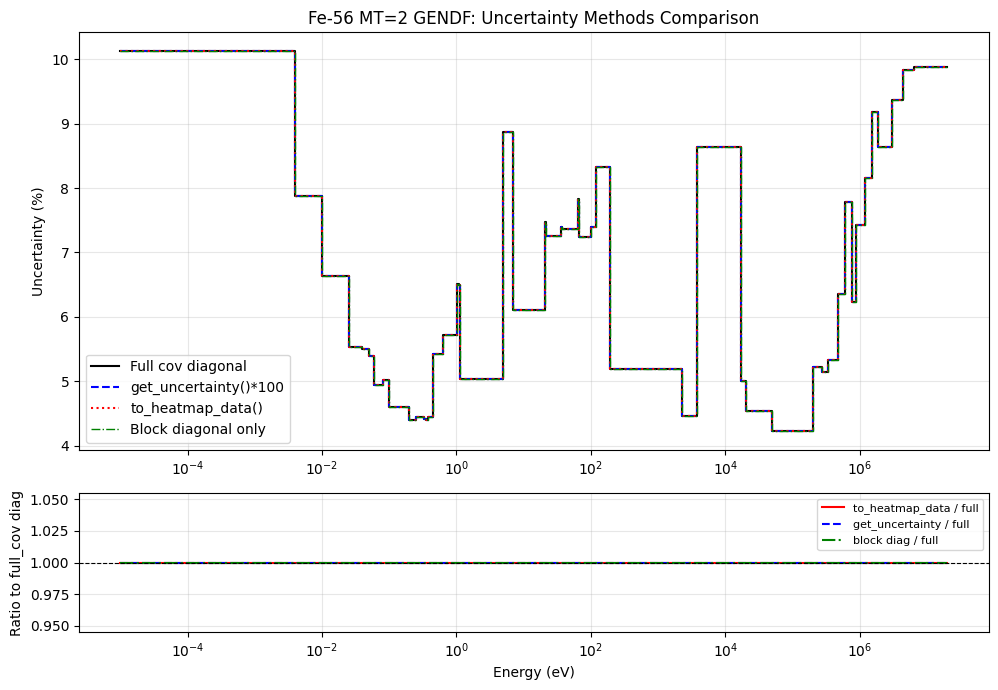

In [4]:
# Step plot comparison
energy_grid = np.array(cov.energy_grid)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.step(energy_grid, np.append(unc_full_pct, unc_full_pct[-1]), where='post',
        label='Full cov diagonal', linewidth=1.5, color='black')
ax.step(energy_grid, np.append(unc_get_pct, unc_get_pct[-1]), where='post',
        label='get_uncertainty()*100', linewidth=1.5, linestyle='--', color='blue')
ax.step(energy_grid, np.append(unc_heatmap_pct, unc_heatmap_pct[-1]), where='post',
        label='to_heatmap_data()', linewidth=1.5, linestyle=':', color='red')
ax.step(energy_grid, np.append(unc_block_pct, unc_block_pct[-1]), where='post',
        label='Block diagonal only', linewidth=1.0, linestyle='-.', color='green')
ax.set_xscale('log')
ax.set_ylabel('Uncertainty (%)')
ax.legend()
ax.set_title('Fe-56 MT=2 GENDF: Uncertainty Methods Comparison')
ax.grid(True, alpha=0.3)

# Ratio plot
ax = axes[1]
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_heatmap = np.where(unc_full_pct > 0, unc_heatmap_pct / unc_full_pct, 1.0)
    ratio_get = np.where(unc_full_pct > 0, unc_get_pct / unc_full_pct, 1.0)
    ratio_block = np.where(unc_full_pct > 0, unc_block_pct / unc_full_pct, 1.0)
ax.step(energy_grid, np.append(ratio_heatmap, ratio_heatmap[-1]), where='post',
        label='to_heatmap_data / full', color='red')
ax.step(energy_grid, np.append(ratio_get, ratio_get[-1]), where='post',
        label='get_uncertainty / full', color='blue', linestyle='--')
ax.step(energy_grid, np.append(ratio_block, ratio_block[-1]), where='post',
        label='block diag / full', color='green', linestyle='-.')
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_xscale('log')
ax.set_ylabel('Ratio to full_cov diag')
ax.set_xlabel('Energy (eV)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

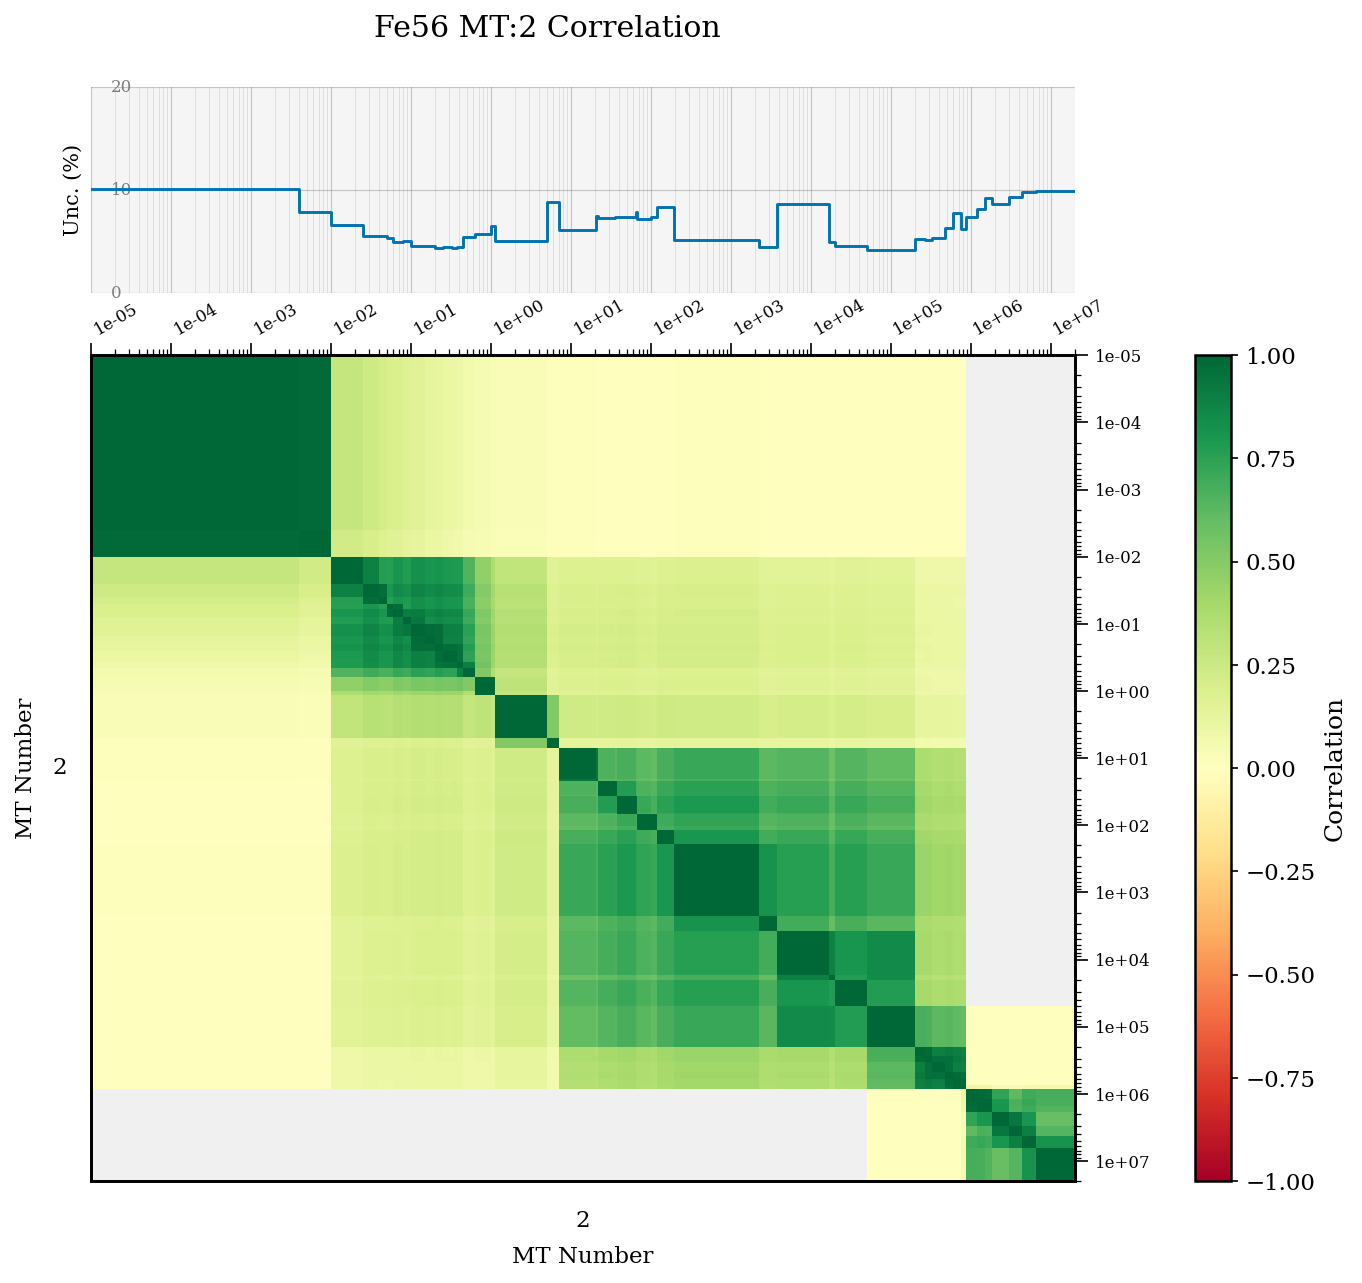

In [5]:
# Heatmap with uncertainty panel
from kika.plotting import HeatmapBuilder

builder = HeatmapBuilder(style='light', figsize=(8, 8), dpi=150)
builder.add_heatmap(heatmap_data, show_uncertainties=True, show_energy_ticks=True)
fig = builder.build()
plt.show()